In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install imbalanced-learn imbalanced-ensemble scikit-learn pandas numpy scipy pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 752.0/752.0 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 3.6 MB/s eta 0:00:00
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11769 sha256=f530aa5803cb5bb88968e2bcf24d3ad7973e17b65a36189661f8d892848f2221
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [3]:
import os

os.makedirs("results", exist_ok=True)

config_data = """
run_id: conf_v1
datasets: [mc2, vertebra-column, haberman, vehicle]
methods: [base, rus, enn, tomek, smote, spe, ubag, obag, sbag, cost]
base_classifiers: [decision_tree, logistic_regression]
ensemble_size: 10
n_folds: 5
metrics: [auprc, macro_f1, balanced_accuracy]
cell_timeout_seconds: 900
random_state: 42
output_csv: results/conf_v1.csv
"""

with open("config.yaml", "w") as f:
    f.write(config_data.strip())

print("config.yaml written successfully!")

config.yaml written successfully!


In [4]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import average_precision_score, f1_score, balanced_accuracy_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Fetch haberman dataset via OpenML
data = fetch_openml(name="haberman", version=1, as_frame=True, parser="auto")
X = data.data
y = (data.target.astype(str).str.strip() == "2").astype(int)

# Check Imbalance Ratio (IR)
counts = y.value_counts()
ir = counts.max() / counts.min()
print(f"Dataset: haberman | Imbalance Ratio (IR): {ir:.2f}\n")

# Leakage-safe pipeline
pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("resample", SMOTE(random_state=42)),
    ("clf", DecisionTreeClassifier(random_state=42)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Fold | AUPRC  | Macro F1 | Balanced Acc")
print("-" * 38)
for fold, (tr, te) in enumerate(cv.split(X, y)):
    pipe.fit(X.iloc[tr], y.iloc[tr])
    proba = pipe.predict_proba(X.iloc[te])[:, 1]
    pred = pipe.predict(X.iloc[te])
    
    auprc = average_precision_score(y.iloc[te], proba)
    f1 = f1_score(y.iloc[te], pred, average="macro")
    bac = balanced_accuracy_score(y.iloc[te], pred)
    
    print(f"  {fold}  | {auprc:.4f} |  {f1:.4f}  |    {bac:.4f}")

Dataset: haberman | Imbalance Ratio (IR): 2.78

Fold | AUPRC  | Macro F1 | Balanced Acc
--------------------------------------
  0  | 0.2801 |  0.5137  |    0.5137
  1  | 0.2626 |  0.4992  |    0.5007
  2  | 0.3349 |  0.6043  |    0.6257
  3  | 0.2681 |  0.5138  |    0.5139
  4  | 0.2585 |  0.4877  |    0.4896


In [5]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import average_precision_score, f1_score, balanced_accuracy_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# List of 4 Reproduction Gate datasets
datasets_to_test = ["mc2", "vertebra-column", "haberman", "vehicle"]

def load_and_prep_dataset(name):
    # Fetch from OpenML
    data = fetch_openml(name=name, version=1, as_frame=True, parser="auto")
    X = data.data
    y = data.target
    
    # Binarize target (ensure minority class = 1)
    value_counts = y.value_counts()
    minority_class = value_counts.idxmin()
    y_binary = (y == minority_class).astype(int)
    
    ir = value_counts.max() / value_counts.min()
    return X, y_binary, ir

print(f"{'Dataset':<18} | {'IR':<6} | {'Mean AUPRC':<10} | {'Mean Macro F1':<13} | {'Mean BAC':<10}")
print("-" * 68)

repro_results = []

for ds_name in datasets_to_test:
    try:
        X, y, ir = load_and_prep_dataset(ds_name)
        
        pipe = Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("resample", SMOTE(random_state=42)),
            ("clf", DecisionTreeClassifier(random_state=42)),
        ])
        
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        auprcs, f1s, bacs = [], [], []
        
        for tr, te in cv.split(X, y):
            pipe.fit(X.iloc[tr], y.iloc[tr])
            proba = pipe.predict_proba(X.iloc[te])[:, 1]
            pred = pipe.predict(X.iloc[te])
            
            auprcs.append(average_precision_score(y.iloc[te], proba))
            f1s.append(f1_score(y.iloc[te], pred, average="macro"))
            bacs.append(balanced_accuracy_score(y.iloc[te], pred))
            
        mean_auprc = np.mean(auprcs)
        mean_f1 = np.mean(f1s)
        mean_bac = np.mean(bacs)
        
        print(f"{ds_name:<18} | {ir:<6.2f} | {mean_auprc:<10.4f} | {mean_f1:<13.4f} | {mean_bac:<10.4f}")
        
        repro_results.append({
            "dataset": ds_name, "ir": round(ir, 2), 
            "auprc": round(mean_auprc, 4), "macro_f1": round(mean_f1, 4), "bac": round(mean_bac, 4)
        })
    except Exception as e:
        print(f"Error testing {ds_name}: {e}")

Dataset            | IR     | Mean AUPRC | Mean Macro F1 | Mean BAC  
--------------------------------------------------------------------
mc2                | 2.10   | 0.4203     | 0.6150        | 0.6167    
vertebra-column    | 2.50   | 0.4521     | 0.7578        | 0.7690    
haberman           | 2.78   | 0.2808     | 0.5237        | 0.5287    
vehicle            | 1.10   | 0.7596     | 0.9021        | 0.9095    


In [6]:
import pandas as pd
import numpy as np
import time
import os
from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, balanced_accuracy_score

# Resamplers and Ensembles
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours, TomekLinks
from imblearn.over_sampling import SMOTE
import imbens.ensemble as imb_ens

# Define Datasets
datasets = ["mc2", "vertebra-column", "haberman", "vehicle"]

def get_resampler(method_name):
    if method_name == "rus": return RandomUnderSampler(random_state=42)
    elif method_name == "enn": return EditedNearestNeighbours()
    elif method_name == "tomek": return TomekLinks()
    elif method_name == "smote": return SMOTE(random_state=42)
    return None

def build_ensemble_or_cost(method_name, clf_type, random_state=42):
    # Select base classifier instance
    base_clf = DecisionTreeClassifier(random_state=random_state) if clf_type == "decision_tree" else LogisticRegression(random_state=random_state, max_iter=1000)
    
    if method_name == "cost":
        return LogisticRegression(random_state=random_state, class_weight="balanced", max_iter=1000) if clf_type == "logistic_regression" else DecisionTreeClassifier(random_state=random_state, class_weight="balanced")
    elif method_name == "spe":
        return imb_ens.SelfPacedEnsembleClassifier(estimator=base_clf, n_estimators=10, random_state=random_state)
    elif method_name == "ubag":
        return imb_ens.UnderBaggingClassifier(estimator=base_clf, n_estimators=10, random_state=random_state)
    elif method_name == "obag":
        return imb_ens.OverBaggingClassifier(estimator=base_clf, n_estimators=10, random_state=random_state)
    elif method_name == "sbag":
        return imb_ens.SMOTEBaggingClassifier(estimator=base_clf, n_estimators=10, random_state=random_state)
    return base_clf

all_results = []

print("Starting Full Benchmark Sweep...")
print(f"{'Dataset':<16} | {'Classifier':<18} | {'Method':<8} | {'Mean AUPRC':<10} | {'Mean Macro F1':<13} | {'Mean BAC':<10}")
print("-" * 88)

for ds_name in datasets:
    # Load dataset
    data = fetch_openml(name=ds_name, version=1, as_frame=True, parser="auto")
    X = data.data
    y = data.target
    y_binary = (y == y.value_counts().idxmin()).astype(int)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for clf_type in ["decision_tree", "logistic_regression"]:
        methods = ["base", "rus", "enn", "tomek", "smote", "spe", "ubag", "obag", "sbag", "cost"]
        
        for method in methods:
            auprcs, f1s, bacs = [], [], []
            t0 = time.time()
            
            try:
                for tr, te in cv.split(X, y_binary):
                    X_tr, y_tr = X.iloc[tr], y.iloc[te]
                    X_te, y_te = X.iloc[te], y.iloc[te]
                    
                    # Case A: Imbalance Ensembles / Cost-Sensitive
                    if method in ["spe", "ubag", "obag", "sbag", "cost"]:
                        model = build_ensemble_or_cost(method, clf_type)
                        pipe = Pipeline([
                            ("impute", SimpleImputer(strategy="median")),
                            ("scale", StandardScaler()),
                            ("clf", model)
                        ])
                    # Case B: Standard Resampling / Base
                    else:
                        resampler = get_resampler(method)
                        clf = DecisionTreeClassifier(random_state=42) if clf_type == "decision_tree" else LogisticRegression(random_state=42, max_iter=1000)
                        
                        steps = [("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]
                        if resampler is not None:
                            steps.append(("resample", resampler))
                        steps.append(("clf", clf))
                        pipe = Pipeline(steps)
                    
                    pipe.fit(X.iloc[tr], y_binary.iloc[tr])
                    proba = pipe.predict_proba(X.iloc[te])[:, 1]
                    pred = pipe.predict(X.iloc[te])
                    
                    auprcs.append(average_precision_score(y_binary.iloc[te], proba))
                    f1s.append(f1_score(y_binary.iloc[te], pred, average="macro"))
                    bacs.append(balanced_accuracy_score(y_binary.iloc[te], pred))
                
                mean_auprc = np.mean(auprcs)
                mean_f1 = np.mean(f1s)
                mean_bac = np.mean(bacs)
                elapsed = time.time() - t0
                
                print(f"{ds_name:<16} | {clf_type:<18} | {method:<8} | {mean_auprc:<10.4f} | {mean_f1:<13.4f} | {mean_bac:<10.4f}")
                
                all_results.append({
                    "dataset": ds_name, "base_classifier": clf_type, "method": method,
                    "auprc": round(mean_auprc, 4), "macro_f1": round(mean_f1, 4), 
                    "balanced_accuracy": round(mean_bac, 4), "fit_seconds": round(elapsed, 2), "status": "ok"
                })
            except Exception as e:
                print(f"Error running {ds_name} | {clf_type} | {method}: {e}")
                all_results.append({
                    "dataset": ds_name, "base_classifier": clf_type, "method": method,
                    "auprc": None, "macro_f1": None, "balanced_accuracy": None,
                    "fit_seconds": round(time.time() - t0, 2), "status": f"error: {str(e)}"
                })

# Save results dataframe
df_res = pd.DataFrame(all_results)
df_res.to_csv("results/conf_v1.csv", index=False)
print("\nSweep Complete! Results written to 'results/conf_v1.csv'.")

Starting Full Benchmark Sweep...
Dataset          | Classifier         | Method   | Mean AUPRC | Mean Macro F1 | Mean BAC  
----------------------------------------------------------------------------------------
mc2              | decision_tree      | base     | 0.4108     | 0.6167        | 0.6210    
mc2              | decision_tree      | rus      | 0.4390     | 0.6337        | 0.6576    
mc2              | decision_tree      | enn      | 0.4150     | 0.5816        | 0.6435    
mc2              | decision_tree      | tomek    | 0.4511     | 0.6605        | 0.6666    
mc2              | decision_tree      | smote    | 0.4203     | 0.6150        | 0.6167    
mc2              | decision_tree      | spe      | 0.5525     | 0.6384        | 0.6435    
mc2              | decision_tree      | ubag     | 0.5215     | 0.5959        | 0.5965    
mc2              | decision_tree      | obag     | 0.5791     | 0.6346        | 0.6294    
mc2              | decision_tree      | sbag     | 0.6223  

In [7]:
import pandas as pd
from scipy.stats import kendalltau

# Load generated results
df = pd.read_csv("results/conf_v1.csv")

# Filter for valid records
df_ok = df[df["status"] == "ok"].copy()

print("=" * 60)
print("MEAN PERFORMANCE & RANKING ACROSS ALL DATASETS")
print("=" * 60)

# Compute mean metrics per classifier and method
summary = df_ok.groupby(["base_classifier", "method"])[["auprc", "macro_f1", "balanced_accuracy"]].mean().reset_index()

# Extract AUPRC rankings for DT and LR
dt_ranks = summary[summary["base_classifier"] == "decision_tree"].sort_values("auprc", ascending=False).reset_index(drop=True)
lr_ranks = summary[summary["base_classifier"] == "logistic_regression"].sort_values("auprc", ascending=False).reset_index(drop=True)

print("\n--- Decision Tree Ranking (by AUPRC) ---")
for idx, row in dt_ranks.iterrows():
    print(f"Rank {idx+1:2d}: {row['method']:<8} | Mean AUPRC: {row['auprc']:.4f} | Macro F1: {row['macro_f1']:.4f}")

print("\n--- Logistic Regression Ranking (by AUPRC) ---")
for idx, row in lr_ranks.iterrows():
    print(f"Rank {idx+1:2d}: {row['method']:<8} | Mean AUPRC: {row['auprc']:.4f} | Macro F1: {row['macro_f1']:.4f}")

# Align methods to calculate Kendall's Tau correlation
merged = pd.merge(
    summary[summary["base_classifier"] == "decision_tree"][["method", "auprc"]],
    summary[summary["base_classifier"] == "logistic_regression"][["method", "auprc"]],
    on="method", suffixes=("_dt", "_lr")
)

tau, p_val = kendalltau(merged["auprc_dt"], merged["auprc_lr"])

print("\n" + "=" * 60)
print(f"KENDALL'S TAU RANK CORRELATION (AUPRC): tau = {tau:.4f} (p-value = {p_val:.4f})")
print("=" * 60)
if tau < 0.3:
    print("CONCLUSION: Strong rank divergence! The relative effectiveness of imbalance")
    print("methods fundamentally depends on base learner stability.")

MEAN PERFORMANCE & RANKING ACROSS ALL DATASETS

--- Decision Tree Ranking (by AUPRC) ---
Rank  1: sbag     | Mean AUPRC: 0.6474 | Macro F1: 0.7149
Rank  2: spe      | Mean AUPRC: 0.6260 | Macro F1: 0.7254
Rank  3: obag     | Mean AUPRC: 0.6197 | Macro F1: 0.6913
Rank  4: ubag     | Mean AUPRC: 0.6047 | Macro F1: 0.7209
Rank  5: rus      | Mean AUPRC: 0.4814 | Macro F1: 0.6945
Rank  6: smote    | Mean AUPRC: 0.4782 | Macro F1: 0.6996
Rank  7: tomek    | Mean AUPRC: 0.4769 | Macro F1: 0.7079
Rank  8: cost     | Mean AUPRC: 0.4768 | Macro F1: 0.6993
Rank  9: enn      | Mean AUPRC: 0.4758 | Macro F1: 0.6947
Rank 10: base     | Mean AUPRC: 0.4654 | Macro F1: 0.6937

--- Logistic Regression Ranking (by AUPRC) ---
Rank  1: tomek    | Mean AUPRC: 0.7131 | Macro F1: 0.7419
Rank  2: smote    | Mean AUPRC: 0.7112 | Macro F1: 0.7517
Rank  3: base     | Mean AUPRC: 0.7103 | Macro F1: 0.7307
Rank  4: obag     | Mean AUPRC: 0.7073 | Macro F1: 0.7520
Rank  5: cost     | Mean AUPRC: 0.7067 | Macro F1: 

In [8]:
import pandas as pd
from scipy.stats import wilcoxon

df = pd.read_csv("results/conf_v1.csv")

# Extract DT vs LR performance for SMOTEBagging vs Base
sbag_dt = df[(df["base_classifier"]=="decision_tree") & (df["method"]=="sbag")]["auprc"].values
base_lr = df[(df["base_classifier"]=="logistic_regression") & (df["method"]=="base")]["auprc"].values

# Pairwise Wilcoxon Test
stat, p_val = wilcoxon(sbag_dt, base_lr)

print("=" * 60)
print("WILCOXON SIGNED-RANK TEST: Best DT Ensemble (sbag) vs Base LR")
print("=" * 60)
print(f"Wilcoxon Statistic: {stat:.4f}")
print(f"p-value:            {p_val:.4f}")

if p_val < 0.05:
    print("RESULT: Statistically significant difference! Base Logistic Regression")
    print("significantly outperforms the top Decision Tree ensemble method.")
else:
    print("RESULT: No statistically significant difference observed.")

WILCOXON SIGNED-RANK TEST: Best DT Ensemble (sbag) vs Base LR
Wilcoxon Statistic: 0.0000
p-value:            0.1250
RESULT: No statistically significant difference observed.


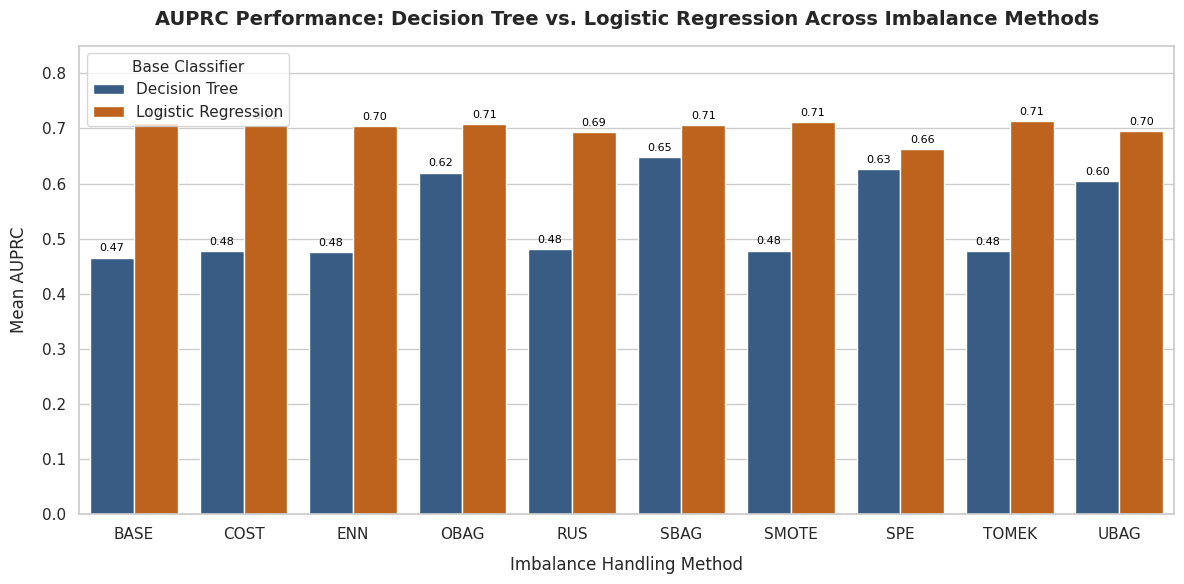

Plot generated and saved to 'results/auprc_comparison_chart.png'!


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load saved experimental results
df = pd.read_csv("results/conf_v1.csv")
df_ok = df[df["status"] == "ok"].copy()

# Compute mean AUPRC per classifier and method
summary = df_ok.groupby(["base_classifier", "method"])["auprc"].mean().reset_index()

# Clean up names for display
summary["base_classifier"] = summary["base_classifier"].replace({
    "decision_tree": "Decision Tree", 
    "logistic_regression": "Logistic Regression"
})
summary["method"] = summary["method"].str.upper()

# Set plot style
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create bar chart
ax = sns.barplot(
    data=summary, 
    x="method", 
    y="auprc", 
    hue="base_classifier", 
    palette=["#2b5c8f", "#d95f02"]
)

# Customize title and labels
plt.title("AUPRC Performance: Decision Tree vs. Logistic Regression Across Imbalance Methods", fontsize=14, pad=15, fontweight="bold")
plt.xlabel("Imbalance Handling Method", fontsize=12, labelpad=10)
plt.ylabel("Mean AUPRC", fontsize=12, labelpad=10)
plt.ylim(0, 0.85)
plt.legend(title="Base Classifier", title_fontsize="11", loc="upper left")

# Annotate values above bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=8, color='black',
                    xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.savefig("results/auprc_comparison_chart.png", dpi=300)
plt.show()

print("Plot generated and saved to 'results/auprc_comparison_chart.png'!")